# ESC SPMe: Plot I, V, T, and SOC for all cells

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Define parameter functions

In [3]:
from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    # E_D_s = 42770
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9

    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.246491535,0.177990605,0.109487916][-1:0:-1])
    # k_fit = np.array([0.998960993,0.962562613,1.088848875,0.960830764,0.980577779,0.767837023,0.826562007,0.192714141,0.571586523,0.725658028][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref*k #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    # E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.451992894,0.383496394,0.31499461,0.246491535,0.109487916][-1:0:-1])
    # k_fit = np.array([1.224990159,0.918644845,0.646317414,0.418199795,0.250350793,0.318672366,0.267289649,0.182154457,0.11139899,0.329794626,0.337200374,0.418978523][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref *k #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )


# Load data

In [4]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature'][data['Cell Temperature']>140] = None
    data.interpolate(inplace=True)
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(0.75, '75')[0])

C:\Users\Vivian\AppData\Local\Temp\ipykernel_12240\1081016662.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)


,t,V,Temp,I,F,I_C,SOC
0,0.000,3.907343,21.886238,0.832958,0.000000,0.181078,0.749301
1,0.100,1.447498,21.965434,230.630669,0.190512,50.137102,0.747918
2,0.200,1.408588,21.896138,227.542398,0.730296,49.465739,0.746547
3,0.300,1.388854,21.866438,226.594000,0.825552,49.259565,0.745182
4,0.400,1.379884,21.995131,225.494177,0.984312,49.020473,0.743822
...,...,...,...,...,...,...,...
8996,899.607,0.016445,67.207862,3.578503,-59.280996,0.777935,0.132710
8997,899.707,0.016366,67.198277,3.526700,-59.471508,0.766674,0.132689
8998,899.807,0.016405,67.198277,3.530685,-59.185740,0.767540,0.132668
8999,899.907,0.016366,67.188692,3.538654,-59.503260,0.769273,0.132646


# Run simulations

In [5]:
param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }

In [6]:
Cps = {'100A': 1.20962392, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
hs = {'100A': 19.99019775, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175} 
R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007}
R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067}
k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

Cps.update({'avg': np.mean([Cps[k] for k in Cps.keys()])})
hs.update({'avg': np.mean([hs[k] for k in hs.keys()])})
R_tabs.update({'avg': np.mean([R_tabs[k] for k in R_tabs.keys()])})
# R_tabs.update({'avg': 0})
R_escs.update({'avg': np.mean([R_escs[k] for k in R_escs.keys()])})
k_A_sei.update({'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()])})

In [7]:
t_end = 15*60
def sim_ESC(SOC_0, SOC_name, param_update = {}, SOC_param = "", k_h_sei = 1):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    data, T_amb = load_data(SOC_0, SOC_name)
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    R_ext = pybamm.Parameter("External resistance [Ohm]")
#     k_hs =[33.15978564710515, 32.06030657811052, 36.78712046658352, 36.67410927274155]
# k_Cps = [2.5383956970725863, 2.193498353654363, 1.7766323740122707, 1.7656000215073049]

    # [17.81984063  1.09465293] #100F%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [19.99019775  1.20962392] #100%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [19.81810618  0.96645967] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [20.00621175  1.0120845 ] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1] 

    Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
    hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
    # Cps = {'100A': 2.5383956970725863, '100B': 2.193498353654363, '75': 1.7766323740122707, '50': 1.7656000215073049}    # 12/30 test   
    # hs = {'100A': 33.15978564710515, '100B': 32.06030657811052, '75': 36.78712046658352, '50': 36.67410927274155}   
    # R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078, '50':0.007}
    # R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067, '50':0.0067}
    # Cps = {'100A': 2.52552319, '100B': 2.20750941, '75': 1.83004138, '50': 1.79064985}    # 12/29 
    # hs = {'100A': 33.49523017, '100B': 33.09400724, '75': 36.77981673, '50': 35.70433857}
    # Cps = {'100A': 1.20962392, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845} # pre-12/28
    # hs = {'100A': 19.99019775, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
    R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
    R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}
    k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

    # calc avg value
    Cps.update({
        'avg': np.mean([Cps[k] for k in Cps.keys()]),
        # 'avg vent': np.mean([Cps['100A'],Cps['100B'] ]),
        # 'avg no vent': np.mean([Cps['75'],Cps['50'] ]),
        })
    hs.update({
        'avg': np.mean([hs[k] for k in hs.keys()]),
        # 'avg vent': np.mean([hs[k] for k in hs.keys()]),
        # 'avg no vent': np.mean([hs[k] for k in hs.keys()]),
        })
    R_tabs.update({
        'avg': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg':0,
        # 'avg vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg no vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        })
    R_escs.update({
        'avg': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg no vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        })
    k_A_sei.update({
        'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg no vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        })

    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
        # "loss of active material": "electrolyte dryout", 
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    
    param.update({
        # "Initial fraction of Li in SEI": 0.15,
        "Frequency factor for SEI decomposition [s-1]": 2.25E15*k_A_sei[SOC_param],
        "Enthalpy of SEI decomposition [J.kg-1]":257000*k_h_sei,
        # "Number of electrodes connected in parallel to make a cell": 10,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_name],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_name], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb + 273.15,
        "Initial temperature [K]": T_amb + 273.15,
        # "Negative tab width [m]":2.5e-2,
        # "Positive tab width [m]":2.5e-2,
        "Initial cell compression stress [kPa]": data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        # "Negative current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        # "Positive current collector surface heat transfer coefficient [W.m-2.K-1]": h,  
        # "Negative tab heat transfer coefficient [W.m-2.K-1]":h,  
        # "Positive tab heat transfer coefficient [W.m-2.K-1]":h,  
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":hs[SOC_param],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
    }, check_already_exists = False)

    param.update(param_update, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max = 10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) 
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution

# solution = sim_ESC(0.75, '75')


In [8]:
SOC_names = ['100A', '100B', '75', '50']
# SOC_names = ['75', '50']

SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

datas = []
solutions_avg = []
solutions_fit = []

for SOC_name in SOC_names: 
    print(SOC_name)

    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data = load_data(SOC_0, SOC_name)[0]
    solution_avg= sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = 'avg')
    solutions_avg.append(solution_avg)

    solution_fit = sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = SOC_name)
    solutions_fit.append(solution_fit)
    
    datas.append(data)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_12240\1081016662.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_12240\1081016662.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)


100A
100B
75
50


# PLOT: Simulation with average and fitted values

In [9]:
def ocv(soc):
    p0 = np.array([0.114319142120841,  -0.663997904709863, 
            1.686768366470837,  -2.462409468590447,   2.282769243949050, 
            -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
            0.027351974716897,  -0.002866912229499,   0.000171009483610,
            0.000029999998915])*1e5
    return np.polyval(p0,soc)

## Log time

2024-01-09 11:51:46.441 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:51:46.663 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


-28.500000000000014
51.3


2024-01-09 11:51:47.458 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:51:47.681 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


-8.300000000000004
44.3


2024-01-09 11:51:48.566 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:51:48.798 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


62.7
148.6


2024-01-09 11:51:49.582 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:51:49.818 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


900.001


,SOC_names,dSOCs_f,dT_maxs,dsigma_maxs,dt_vents,rmses_I,rmses_I_Tmax,rmses_V_Tmax,rmses_V,rmses_T,rmses_sigma,T_loss_eI
0,100A,-0.07,28.70,-0.40,-28.5,1.17,2.75,0.10,0.04,18.91,5.48,28006.17
1,100B,-0.19,33.81,-18.23,-8.3,2.17,6.24,0.15,0.05,27.82,15.09,22989.83
2,75,0.06,-0.82,26.13,62.7,1.28,4.06,0.15,0.05,9.89,9.99,15595.96
3,50,0.15,-33.10,-8.50,NaN,1.67,5.45,0.14,0.04,16.93,5.33,9309.39


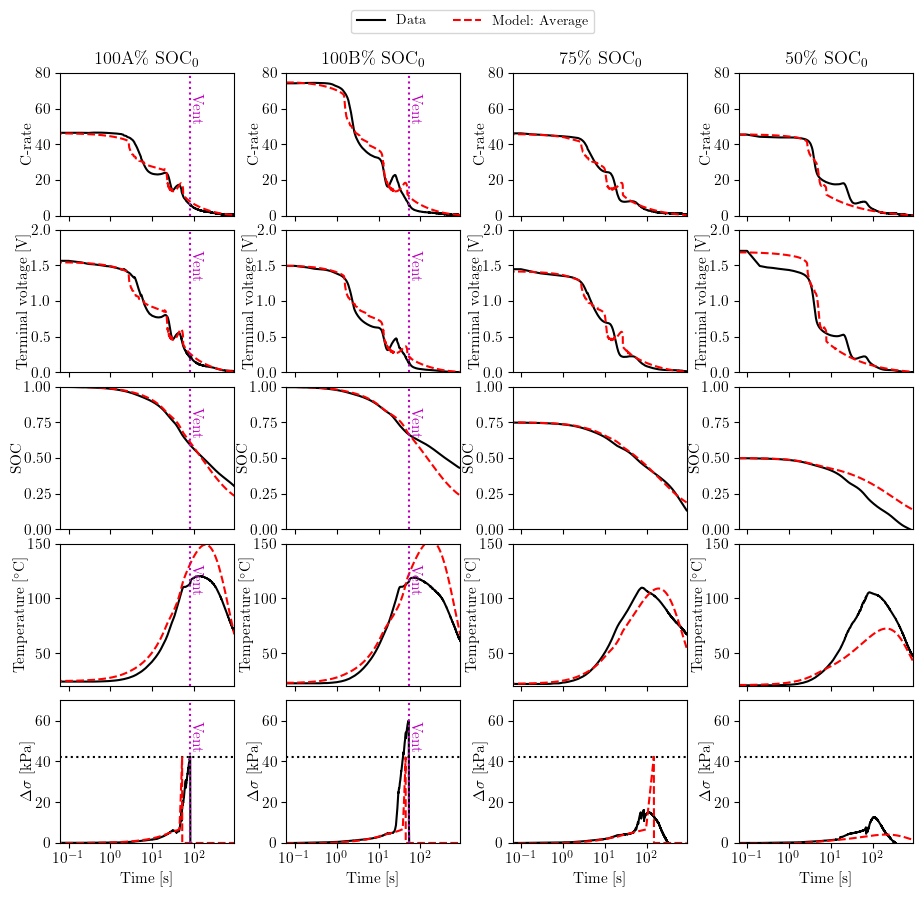

,SOC_names,e_I0,e_V0


In [10]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['Model: Average', 'Model: Fit']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(11, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']


# for each cell...
for k, solutions in enumerate([solutions_avg]): #, solutions_fit]): 
    e_I0 = []
    e_V0 = []
    SOC_names_list= []
    dSOCs_f = []
    dT_maxs = []
    dsigma_maxs = []
    rmses_I = []
    rmses_V = []
    rmses_T = []
    rmses_sigma = []
    dt_vents = []
    rmses_I_Tmax = []
    rmses_V_Tmax = []
    T_loss_eI = []

    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = linestyles[k]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].semilogx(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].semilogx(data.t, data.V,color = data_color)
            ax[2,i].semilogx(data.t, data.SOC,color = data_color)
            ax[3,i].semilogx(data.t, data.Temp,color = data_color)
            ax[4,i].semilogx(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].semilogx(x_plot, I(t), linestyle=sim_ls, color = sim_color, label=sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        e_V = V(t=data.t)  - data.V 
        ax[1,i].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1,i].set_ylim([0,2])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[2,i].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('SOC',labelpad=0)
        ax[2,i].set_ylim([0,1])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[3,i].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[3,i].set_ylim([20,150])
        e_T = T-data.Temp.iloc[0:len(T)]

        sigma_max = 42.35277961, #max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = np.round(data.t[np.where(sigma_plot==0)[0][0]], 4)
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            print(e_t_vent)
        else: 
            t_vent_sim = np.round(data.t.iloc[-1],4)
            e_t_vent = float('nan')
        ax[4,i].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)
        print(t_vent_sim)

        try:
            e_sigma = sigma_plot[np.round(t,4)<t_vent_sim]-  data_sigma[np.round(data.t,4)<t_vent_sim]
        except: 
            continue
        # for t_ref, t_ref_label in zip(t_refs, t_refs_labels):
        #     for j in range(0,5):
        #         ylims = ax[j,i].get_ylim()
        #         ax[j,i].semilogx([t_ref]*2, list(ylims), color = 'grey', linestyle = ':')
        #         if j ==0:
        #             ax[j,i].annotate(t_ref_label, xy=(t_ref, np.diff(ylims)*1+ ylims[0]), rotation=-45, color = 'grey', horizontalalignment = 'center', verticalalignment = 'bottom')
        #             ax[j,i].set_ylim(ylims) # keep original limits
        # for j in range(0,5):
            # ax[j,i].grid(True, axis='x')
        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].semilogx([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.85+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[j,i].set_ylim(ylims) # keep original limits
        if k ==1:
            e_I0.append(e_I[1])
            e_V0.append(V(t=0) - data.V[1])
        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[i])
        dSOCs_f.append(soc[-1] - data.SOC.iloc[-1])
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_I_Tmax.append(np.sqrt(np.mean(np.square(e_I[0:np.where(data.Temp==max(data.Temp))[0][0]]))))
        rmses_V_Tmax.append(np.sqrt(np.mean(np.square(e_V[0:np.where(data.Temp==max(data.Temp))[0][0]]))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))
        idx_T_max = np.where(data.Temp==max(data.Temp))[0][0]
        Q_loss_T_max = np.trapz(I(t=data.t[0:idx_T_max])*param['Nominal cell capacity [A.h]']*(-V(t=data.t[0:idx_T_max])+ocv(soc[0:idx_T_max])),data.t[0:idx_T_max])
        T_loss_eI.append(Q_loss_T_max)
    
    df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_I_Tmax, rmses_V_Tmax, rmses_V, rmses_T,rmses_sigma,T_loss_eI)),
               columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I','rmses_I_Tmax','rmses_V_Tmax', 'rmses_V', 'rmses_T','rmses_sigma','T_loss_eI'])
    display(round(df,2))


# for axs in fig.get_axes():
#     axs.grid()

plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
## fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_log_avg_vs_fit.eps', format='eps', dpi = 300)
plt.savefig('./figs/all_ESC_combined_log_avg.jpg', format='jpg', dpi = 300,bbox_inches='tight')
plt.show()

df = pd.DataFrame(list(zip(SOC_names, e_I0, e_V0)), columns=['SOC_names', 'e_I0', 'e_V0'])
display(df)




## Linear time

2024-01-09 11:54:20.328 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.342 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.381 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.385 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.411 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.415 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.430 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:54:20.434 - [WARNING] processed_variable.__call__(459): Calling varia

-28.5
-8.300000000000011
62.70000000000003
-11.0
-7.300000000000011
26.099999999999994


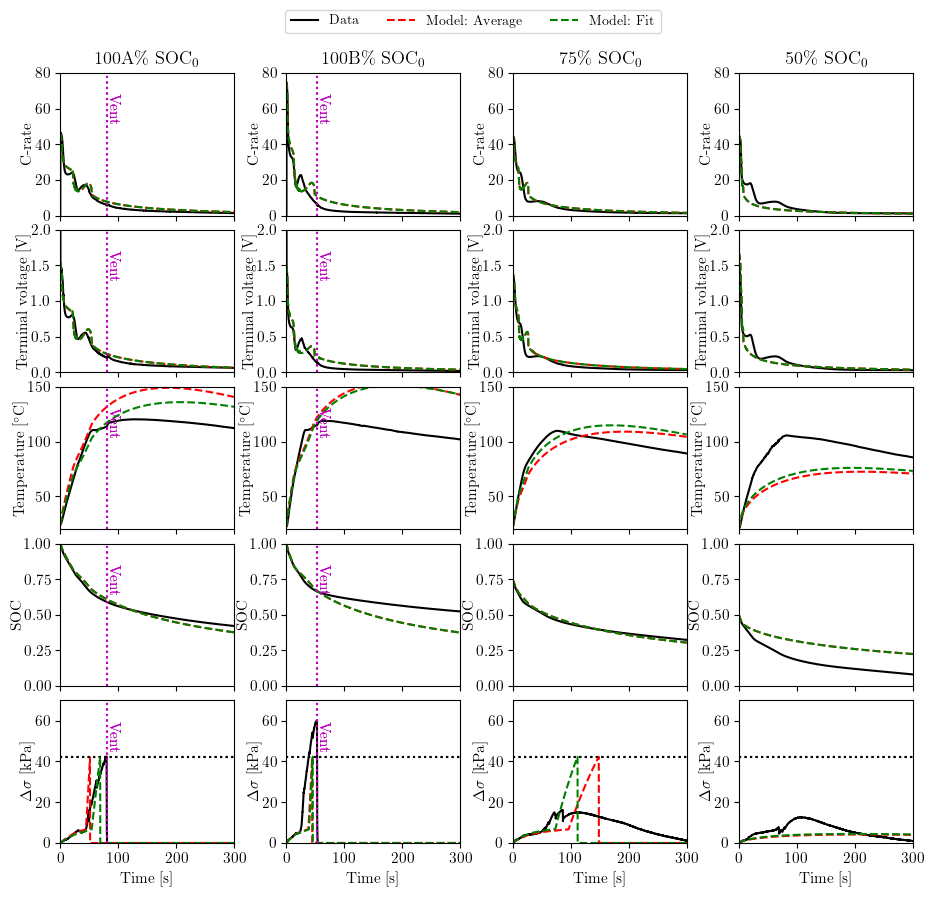

In [17]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['Model: Average', 'Model: Fit']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(11, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']

SOC_names_list = []
dSOCs_f = []
dT_maxs = []
dsigma_maxs = []
rmses_I = []
rmses_V = []
rmses_T = []
rmses_sigma = []
dt_vents = []

# for each cell...
for k, solutions in enumerate([solutions_avg, solutions_fit]): 
    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].plot(data.t, data.V,color = data_color)
            ax[2,i].plot(data.t, data.Temp,color = data_color)
            ax[3,i].plot(data.t, data.SOC,color = data_color)
            ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label=sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        e_V = V(t=data.t)  - data.V 
        ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1,i].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        e_T = T-data.Temp.iloc[0:len(T)]
        ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2,i].set_ylim([20,150])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('SOC',labelpad=0)
        ax[3,i].set_ylim([0,1])

        # sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma_max = 42.35277961, #max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell

        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            print(e_t_vent)
        ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)
        # e_sigma = sigma_plot[t<t_vent_data] -  data_sigma[data.t<t_vent_data]


        # for t_ref, t_ref_label in zip(t_refs, t_refs_labels):
        #     for j in range(0,5):
        #         ylims = ax[j,i].get_ylim()
        #         ax[j,i].semilogx([t_ref]*2, list(ylims), color = 'grey', linestyle = ':')
        #         if j ==0:
        #             ax[j,i].annotate(t_ref_label, xy=(t_ref, np.diff(ylims)*1+ ylims[0]), rotation=-45, color = 'grey', horizontalalignment = 'center', verticalalignment = 'bottom')
        #             ax[j,i].set_ylim(ylims) # keep original limits
        # for j in range(0,5):
            # ax[j,i].grid(True, axis='x')
        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.85+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[j,i].set_ylim(ylims) # keep original limits

        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[i])
        dSOCs_f.append(soc[-1] - data.SOC.iloc[-1])
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        # rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))

# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,300])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear_avg_vs_fit.eps', format='eps', dpi = 300)
plt.show()

# df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_V, rmses_T,rmses_sigma)),
#                columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I', 'rmses_V', 'rmses_T','rmses_sigma'])
# display(round(df,2))


# PLOT: Heat contribution 

In [12]:
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
T_amb_0 = datas[0].Temp[0]

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    # "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":hs['100A'],
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
liion = pybamm.LithiumIonParameters()
Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)
C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
L_x = param.evaluate(pybamm.geometric_parameters.L_x)
L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
V_cell = L*L_y*L_z

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


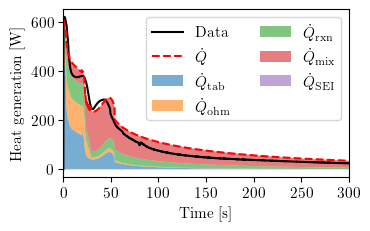

In [13]:
%matplotlib inline

solution = solutions_avg[0]
data = load_data(1, '100A')[0]
# vars to plot
Qs = [
    'Tab heating [W.m-3]',
    'Volume-averaged Ohmic heating [W.m-3]',
    'Volume-averaged irreversible electrochemical heating [W.m-3]',
    'Volume-averaged heat of mixing [W.m-3]',
    'SEI decomposition heating [W.m-3]',
]
labels = [
    '$\dot{Q}_\mathrm{{tab}}$',
    '$\dot{Q}_\mathrm{{ohm}}$',
    '$\dot{Q}_\mathrm{{rxn}}$',
    '$\dot{Q}_\mathrm{{mix}}$',
    '$\dot{Q}_\mathrm{{SEI}}$',
]

# plot total 
t = solution['Time [s]'].entries
xlabel = "Time [s]"
fig, ax = plt.subplots(1,  1, figsize=(4, 2.5), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange', 'm']


Q_total = (solution['Volume-averaged total heating [W.m-3]'].entries)*V_cell
ax.plot(data.t, data.I*(ocv(data.SOC)-data.V), color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
ax.plot(t, Q_total, color = 'r', linestyle = '--', label = '$\dot{Q}$') #$_\mathrm{{total}}$

bottom = [0]*len(t)
for i, (Q,label) in enumerate(zip(Qs, labels)): 
    top = bottom + solution[Q](t)*V_cell
    ax.fill_between(t, bottom, top, alpha = 0.6, label=label)
    bottom = top
    
ax.set_xlim(0,300)
ax.set_xlabel(xlabel)
ax.set_ylabel('Heat generation [W]')
# handles, labels = ax.get_legend_handles_labels()
plt.legend(loc = 'upper right', ncol=2)
plt.savefig('./figs/heat_component.eps', format='eps', dpi = 300)
plt.tight_layout()
plt.show()

# Archive

NameError: name 'solutions_iso' is not defined

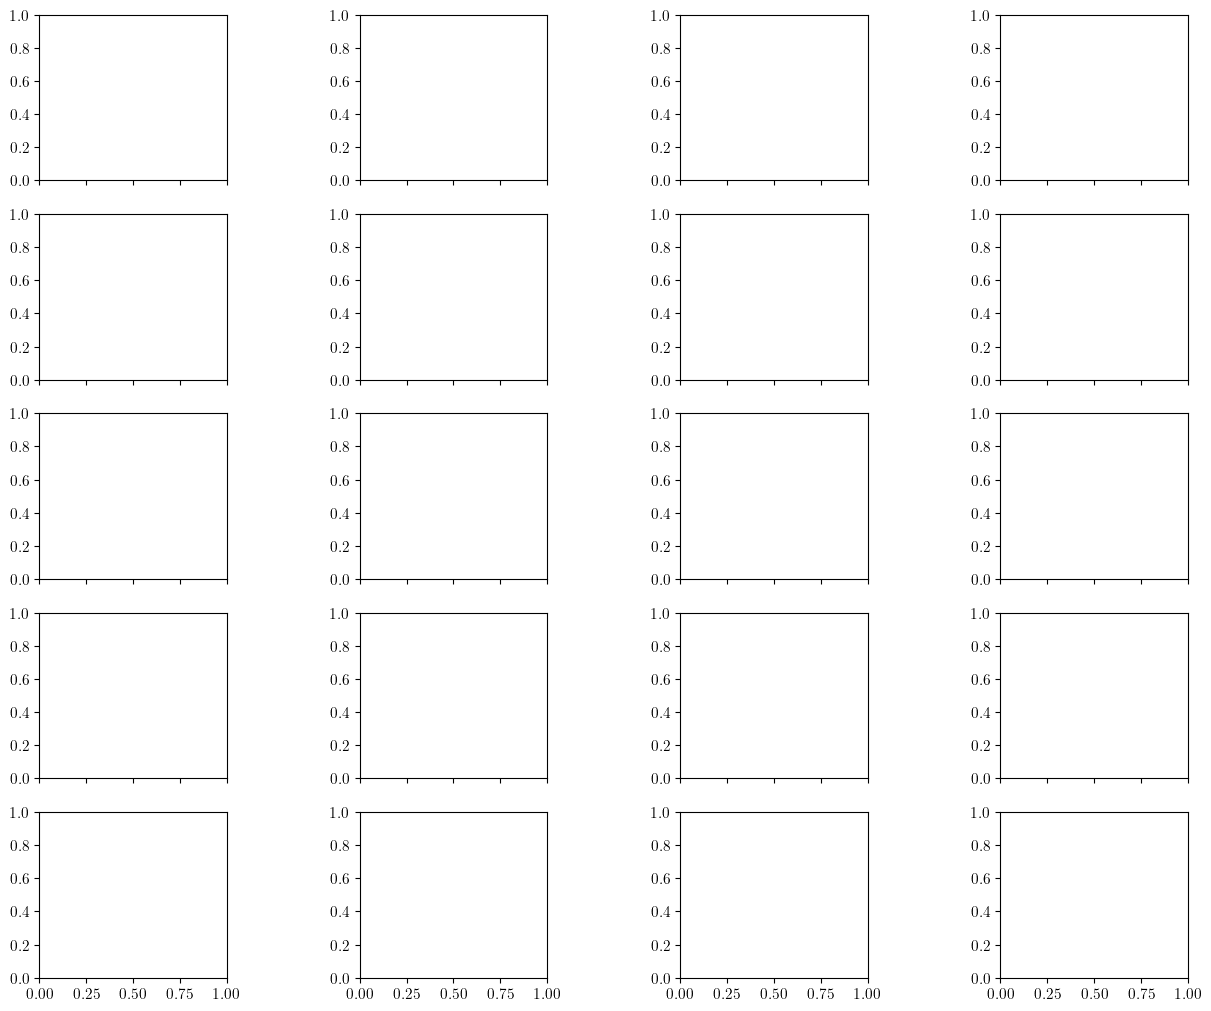

No such comm: e3e6b94057c846038aabca6bfa65e2ff


NameError: name 'solutions_iso' is not defined

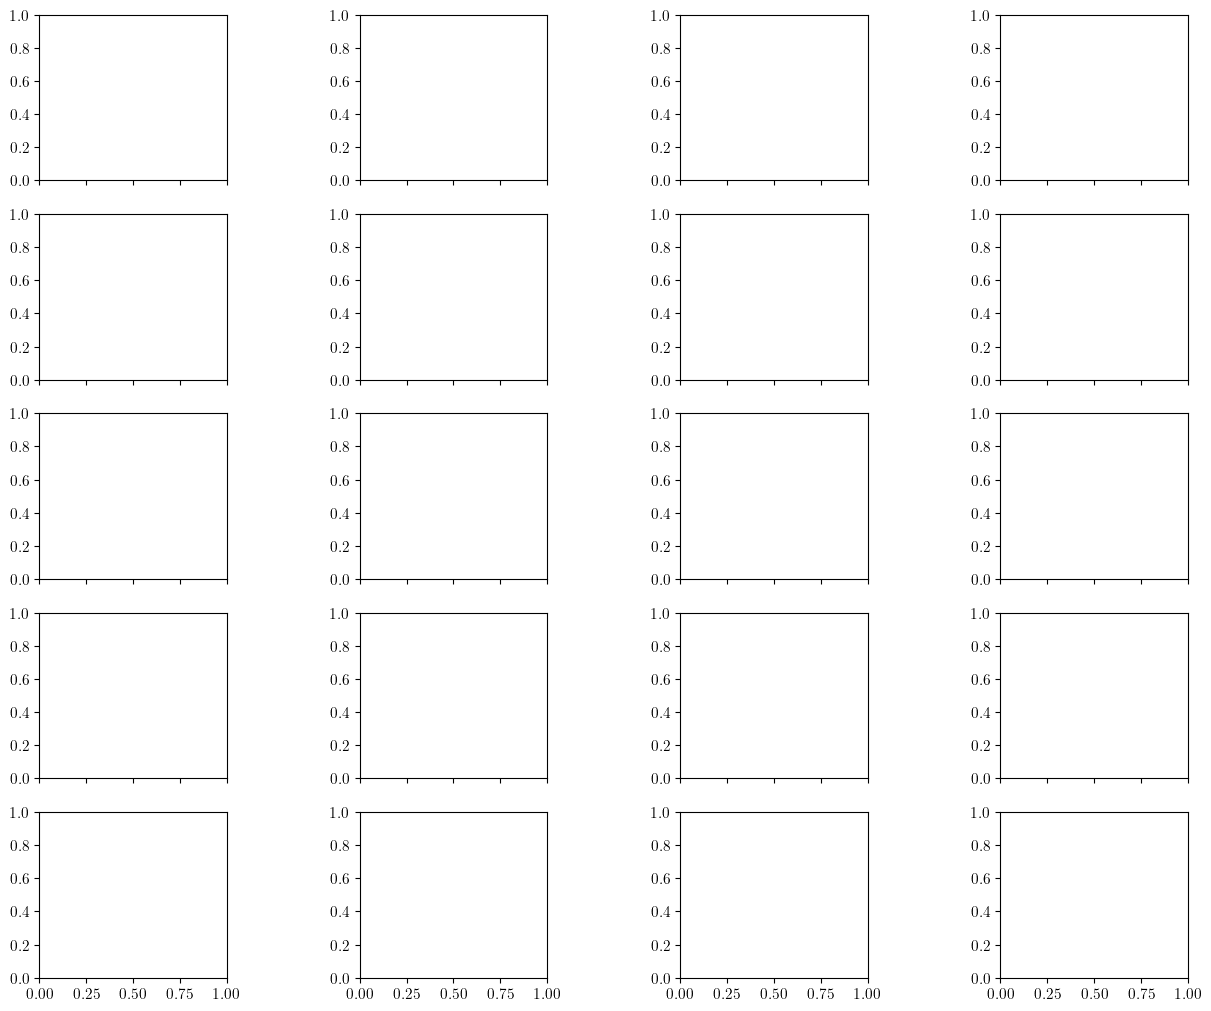

In [14]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions_iso, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].plot(data.t, data.V,color = data_color)
    ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]')
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].plot(data.t, data.Temp,color = data_color)
    ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,150])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].plot(data.t, data.SOC,color = data_color)
    ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear.eps', format='eps', dpi = 300)
plt.show()


2023-10-15 03:06:59.344 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.374 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.404 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.422 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


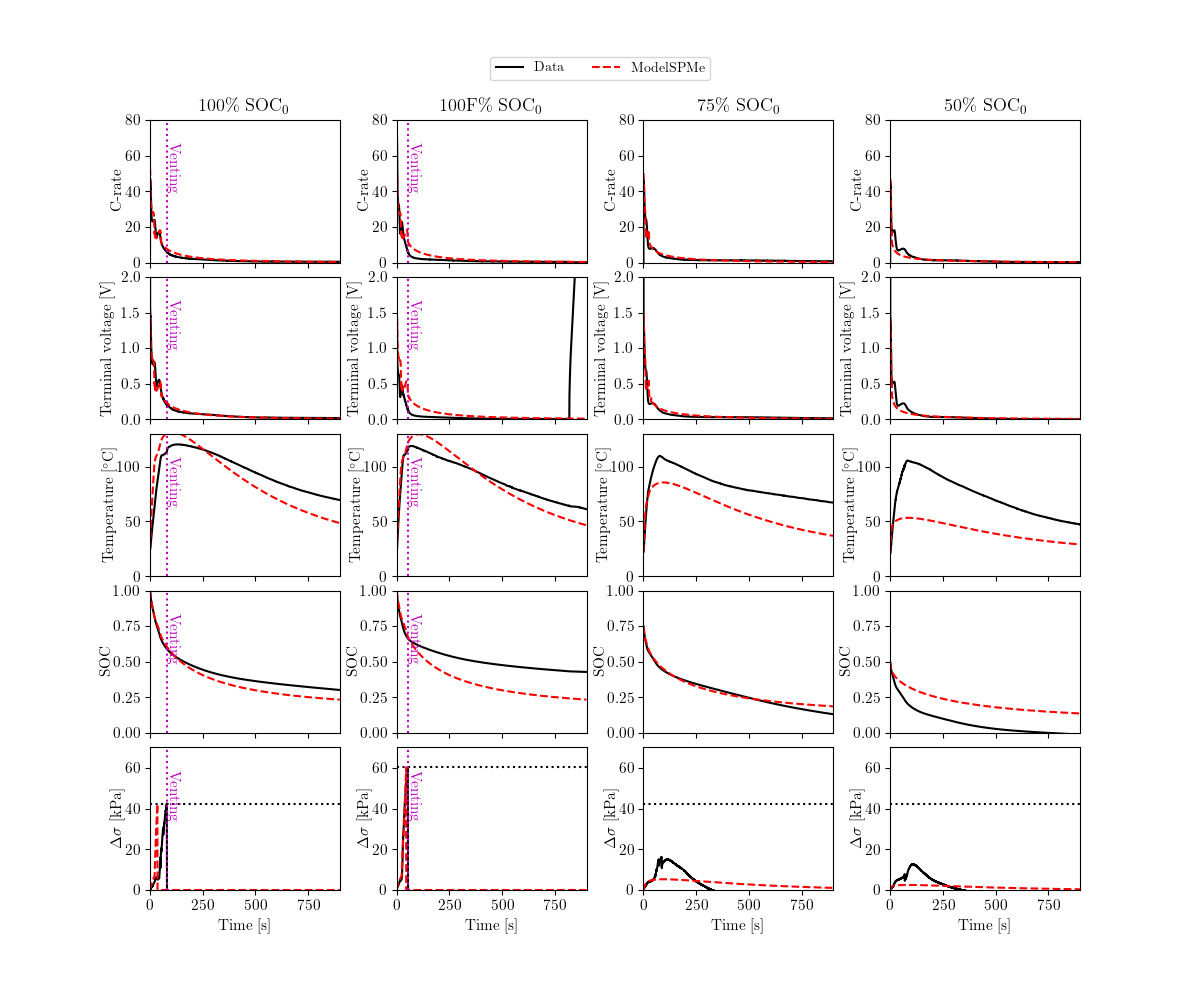

In [ ]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMe', 'SPMeT']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for k, solutions in enumerate([solutions_iso, solutions_therm]): 
    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].plot(data.t, data.V,color = data_color)
            ax[2,i].plot(data.t, data.Temp,color = data_color)
            ax[3,i].plot(data.t, data.SOC,color = data_color)
            ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model' + sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]')
        ax[1,i].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2,i].set_ylim([0,130])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('SOC',labelpad=0)
        ax[3,i].set_ylim([0,1])

        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
        ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)

        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_linear_therm_vs_iso.eps', format='eps', dpi = 300)
plt.show()


2023-10-15 02:48:06.549 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.585 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.617 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.639 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


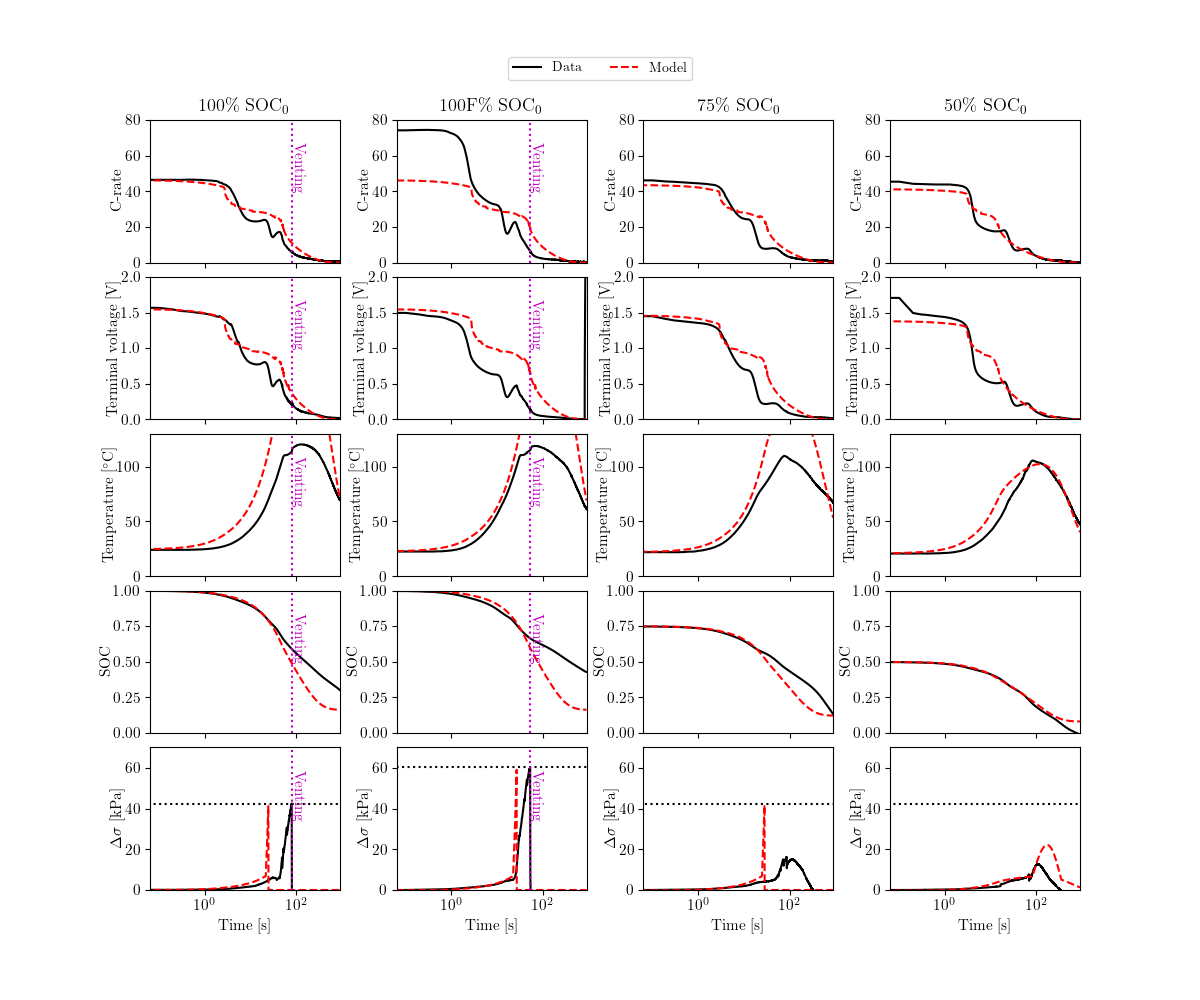

In [ ]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].semilogx(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].semilogx(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].semilogx(data.t, data.V,color = data_color)
    ax[1,i].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]',labelpad=0)
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].semilogx(data.t, data.Temp,color = data_color)
    ax[2,i].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,130])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].semilogx(data.t, data.SOC,color = data_color)
    ax[3,i].semilogx(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].semilogx(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_log.eps', format='eps', dpi = 300)
plt.show()
